<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch08_evaluating_detectors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8: Evaluating Detectors and Parameters

*Outlier Detection in Python* -- Brett Kennedy (Manning, 2024)

---

This chapter tackles the most difficult practical question in outlier detection: **how do we know if our detectors are working well?** Without ground truth labels, evaluation requires a combination of visualization, detector comparison, synthetic data testing, and timing experiments.

We examine the **effect of hyperparameters** (particularly $k$ for neighbor-based detectors), develop techniques to **compare detectors objectively**, introduce **doping** as a method to create pseudo-ground-truth, and measure **execution times** to guide production decisions.

**Key topics:**
- The effect of $k$ on KNN, LOF, and other neighbor-based detectors
- Contour plots to visualize decision boundaries
- Correlation analysis between detector scores
- Doping: modifying real data to create testable synthetic outliers
- AUROC as the standard evaluation metric
- Timing experiments for fit and predict operations

## Environment Setup

In [1]:
!pip install pyod -q 2>/dev/null

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.neighbors import BallTree
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import IsolationForest
import time, warnings
warnings.filterwarnings('ignore')

from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.hbos import HBOS
from pyod.models.cblof import CBLOF
from pyod.models.pca import PCA as PyOD_PCA

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

# Reuse test data from Chapter 7
def create_four_clusters_test_data():
    np.random.seed(0)
    df0 = pd.DataFrame({"A": np.random.normal(25.0, 2.0, 5), "B": np.random.normal(4.0, 2.0, 5)})
    df1 = pd.DataFrame({"A": np.random.normal(1.0, 2.0, 50), "B": np.random.normal(19.0, 2.0, 50)})
    df2 = pd.DataFrame({"A": np.random.normal(1.0, 1.0, 200), "B": np.random.normal(1.0, 1.0, 200)})
    a = np.random.normal(20.0, 3.0, 500)
    df3 = pd.DataFrame({"A": a, "B": np.random.normal(13.0, 3.0, 500) + a})
    df4 = pd.DataFrame([[5.0, 40], [1.5, 8.0], [11.0, 0.5]], columns=['A', 'B'])
    return pd.concat([df0, df1, df2, df3, df4], ignore_index=True)

print("Environment ready. PyOD detectors loaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.8/219.8 kB 12.1 MB/s eta 0:00:00
Environment ready. PyOD detectors loaded.


We reuse the four-cluster test dataset from Chapter 7 throughout this chapter. It contains $758$ points in four clusters of different sizes and densities, plus three global outliers -- a challenging but well-understood scenario for evaluation.

## 8.1 The Effect of the Number of Neighbors ($k$)

The $k$ (or `n_neighbors`) parameter is critical for KNN, LOF, COF, LoOP, LDOF, and ODIN. Setting it well can be the difference between useful and useless results. The key tradeoffs:

- **$k$ too small** (e.g., $k = 3$): High variance. A small cluster of $5$ outliers will be considered normal because each has $3$ close neighbors. Evaluation is based on too few points to be stable.
- **$k$ too large** (e.g., $k = 300$): Points are compared to distant, unrelated regions. Even clearly separated clusters lose their distinction.
- **Sweet spot** ($k \sim 10$--$50$): Large enough for stable estimates, small enough to capture local structure.

**Practical heuristic:** Set $k$ between the size of the smallest cluster you'd consider an outlier group and the size of the smallest cluster you'd consider normal. For example, if clusters of $\leq 10$ are suspicious but clusters of $\geq 50$ are normal, try $k$ in the range $[10, 50]$.

### Figure 8.1: Varying $k$ Across Three Detectors

Figure 8.1a: Effect of k on KNN and LOF (top 25 outliers shown as stars).
Bottom row: averaged over k = [5, 10, 20, 50, 100]


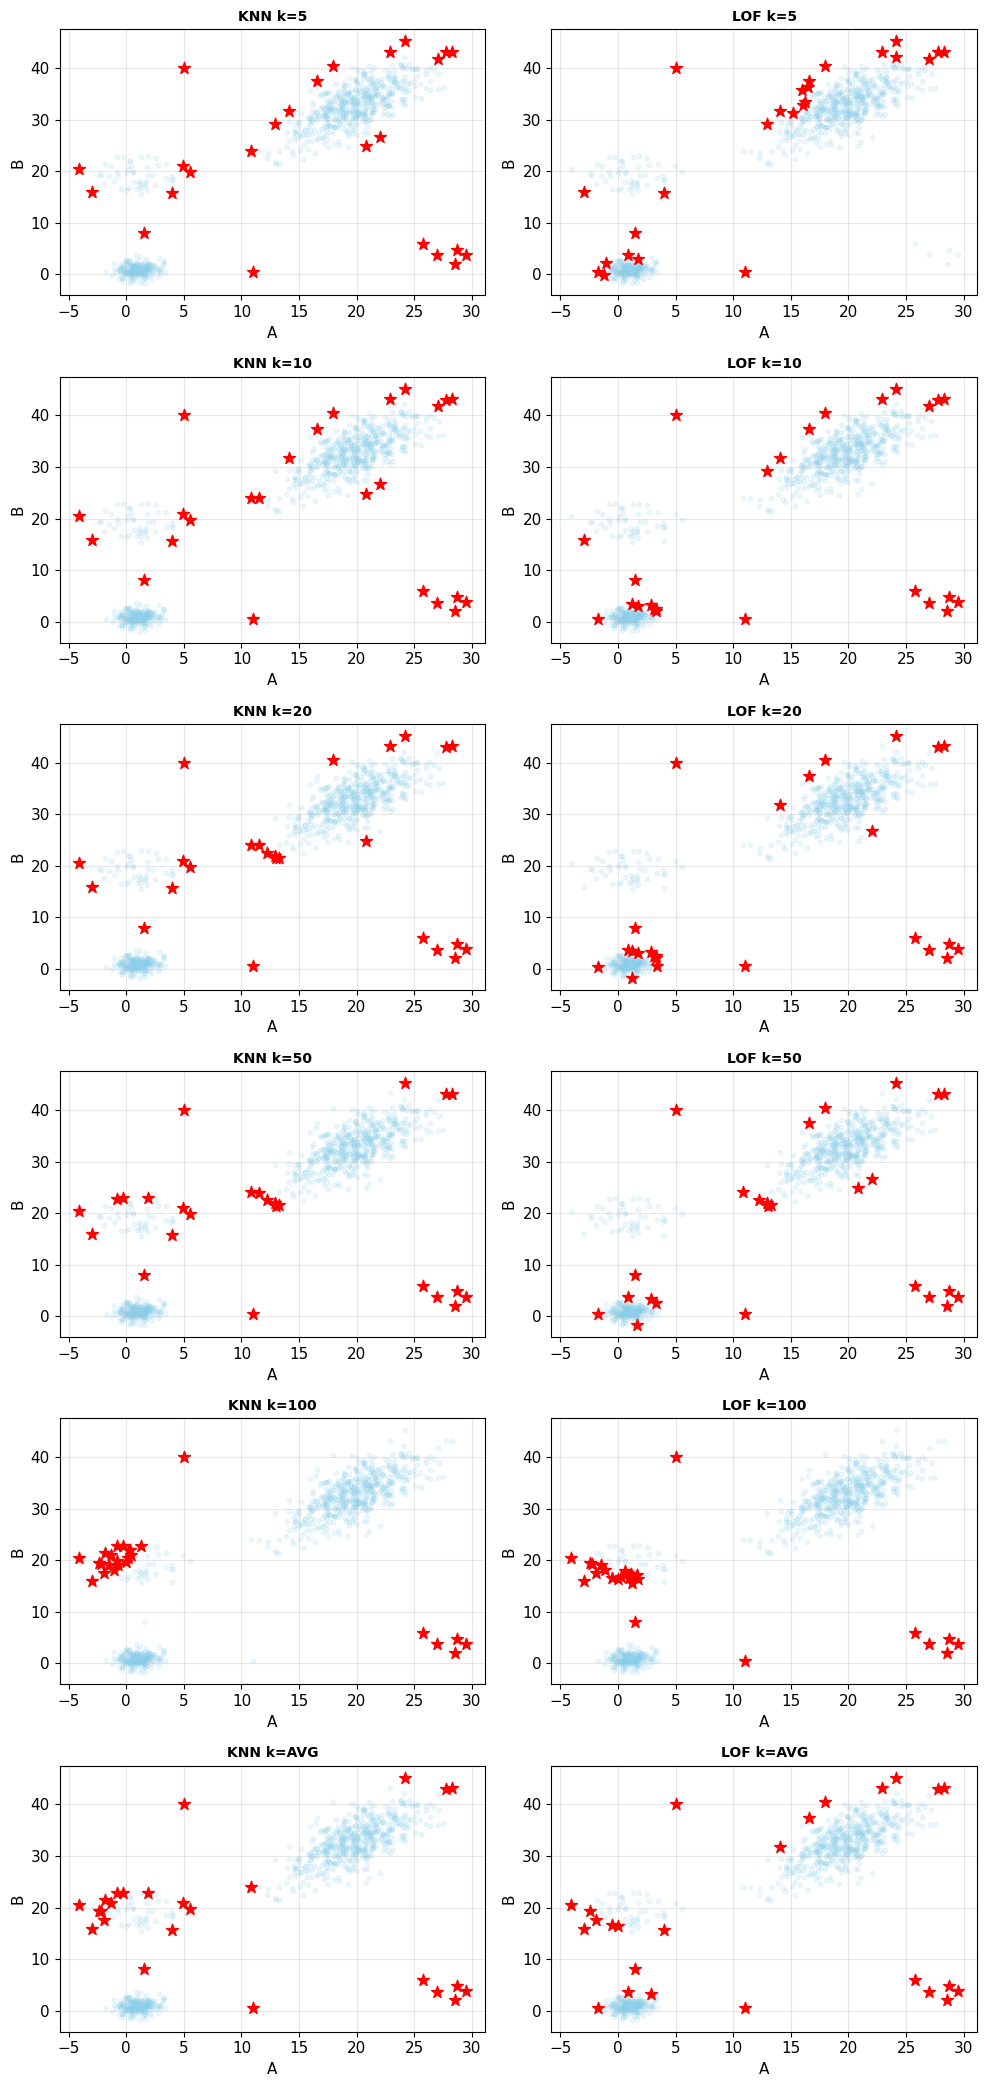

In [2]:
# Figure 8.1a: Effect of varying k on KNN, LOF (3 detectors x 6 k-values + AVG)
df_test = create_four_clusters_test_data()

k_values = [5, 10, 20, 50, 100]
n_top = 25
detectors_config = {
    'KNN': lambda k: KNN(n_neighbors=k, method='mean'),
    'LOF': lambda k: LOF(n_neighbors=k),
}

fig, axes = plt.subplots(len(k_values) + 1, len(detectors_config), figsize=(5*len(detectors_config), 3.5*(len(k_values)+1)))

for col_idx, (det_name, det_fn) in enumerate(detectors_config.items()):
    all_scores = []
    for row_idx, k in enumerate(k_values):
        det = det_fn(k)
        det.fit(df_test[['A','B']])
        scores = det.decision_scores_
        all_scores.append(scores)

        top_mask = np.argsort(scores)[-n_top:]
        ax = axes[row_idx, col_idx]
        ax.scatter(df_test['A'], df_test['B'], alpha=0.15, s=10, c='skyblue')
        ax.scatter(df_test.iloc[top_mask]['A'], df_test.iloc[top_mask]['B'],
                   c='red', s=80, marker='*', zorder=5)
        ax.set_title(f'{det_name} k={k}', fontweight='bold', fontsize=10)
        ax.set_xlabel('A'); ax.set_ylabel('B')

    # Average over all k values
    avg_scores = np.mean(all_scores, axis=0)
    top_mask = np.argsort(avg_scores)[-n_top:]
    ax = axes[-1, col_idx]
    ax.scatter(df_test['A'], df_test['B'], alpha=0.15, s=10, c='skyblue')
    ax.scatter(df_test.iloc[top_mask]['A'], df_test.iloc[top_mask]['B'],
               c='red', s=80, marker='*', zorder=5)
    ax.set_title(f'{det_name} k=AVG', fontweight='bold', fontsize=10)
    ax.set_xlabel('A'); ax.set_ylabel('B')

plt.tight_layout()
print(f"Figure 8.1a: Effect of k on KNN and LOF (top {n_top} outliers shown as stars).")
print(f"Bottom row: averaged over k = {k_values}")

This recreates Figure 8.1a from the book (showing KNN and LOF columns). Key observations:

**KNN with $k=5$**: The small cluster of $5$ outliers (bottom-right) is NOT flagged -- each point has $5$ close neighbors. With $k=100$, even medium clusters start looking outlierish because most points don't have $100$ close neighbors.

**LOF**: More stable across $k$ values because it compares densities *relative to neighbors*. Even with $k=5$, it catches the small cluster because those points are in a sparser region relative to their neighbors.

**Averaged over all $k$ (bottom row)**: Both detectors produce strong, robust results when averaged. This is the chapter's key insight: **averaging over a range of $k$ values is safer than trying to find the "optimal" $k$**, because the average is robust even when some individual $k$ values produce poor results.

### Averaging Over Parameters and Detectors

Figure 8.2: Combined average over detectors and k values.
The three global outliers, small cluster, and cluster-edge points are all captured.


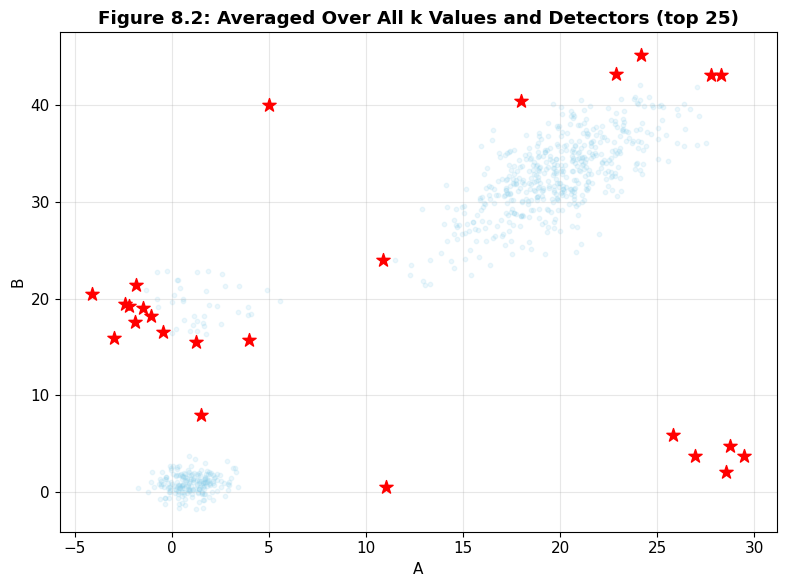

In [3]:
# Listing 8.1-8.2: Averaging over k values and detectors
# Average KNN over multiple k values
scores_arr = []
for k in [5, 10, 20, 50, 100]:
    clf = KNN(n_neighbors=k, method='mean')
    clf.fit(df_test[['A','B']])
    scores_arr.append(clf.decision_scores_)

# Average LOF over multiple k values
lof_scores_arr = []
for k in [5, 10, 20, 50, 100]:
    clf = LOF(n_neighbors=k)
    clf.fit(df_test[['A','B']])
    lof_scores_arr.append(clf.decision_scores_)

# Combine all into scores_df, scale, and average
scores_df = pd.DataFrame({
    'KNN': np.mean(scores_arr, axis=0),
    'LOF': np.mean(lof_scores_arr, axis=0),
})

# Scale each to [0, 1] and average
scaler = MinMaxScaler()
for col in scores_df.columns:
    scores_df[col] = scaler.fit_transform(scores_df[col].values.reshape(-1,1))
scores_df['Avg Score'] = scores_df.mean(axis=1)

n_top = 25
top_mask = np.argsort(scores_df['Avg Score'].values)[-n_top:]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_test['A'], df_test['B'], alpha=0.15, s=10, c='skyblue')
ax.scatter(df_test.iloc[top_mask]['A'], df_test.iloc[top_mask]['B'],
           c='red', s=100, marker='*', zorder=5)
ax.set_title(f'Figure 8.2: Averaged Over All k Values and Detectors (top {n_top})', fontweight='bold')
ax.set_xlabel('A'); ax.set_ylabel('B')
plt.tight_layout()

print("Figure 8.2: Combined average over detectors and k values.")
print("The three global outliers, small cluster, and cluster-edge points are all captured.")

This recreates Figure 8.2 from the book. The averaged result correctly identifies the three global outliers, the small cluster of $5$, and points on the edges of the larger clusters. This is more reliable than any single detector at any single $k$ value.

**The averaging principle**: In outlier detection, we almost never know the optimal parameters. Averaging over a reasonable range produces results that are robust to individual poor choices. This applies to:
- Averaging over $k$ values for a single detector
- Averaging over multiple detectors at a single $k$
- Averaging over both (as done here) for maximum robustness

## 8.2 Contour Plots

**Contour plots** show the decision boundary of a detector across the full 2D space, revealing exactly which regions the detector considers normal (light) vs. anomalous (dark). This is limited to 2D but provides deep insight into how detectors model data.

### Effect of $k$ on KNN Decision Boundaries

Figure 8.5: KNN contour plots with k=3, 10, 300.
  k=3: small cluster is considered NORMAL (each point has 3 neighbors)
  k=10: good balance, small cluster flagged, large clusters normal
  k=300: even medium clusters become somewhat outlierish


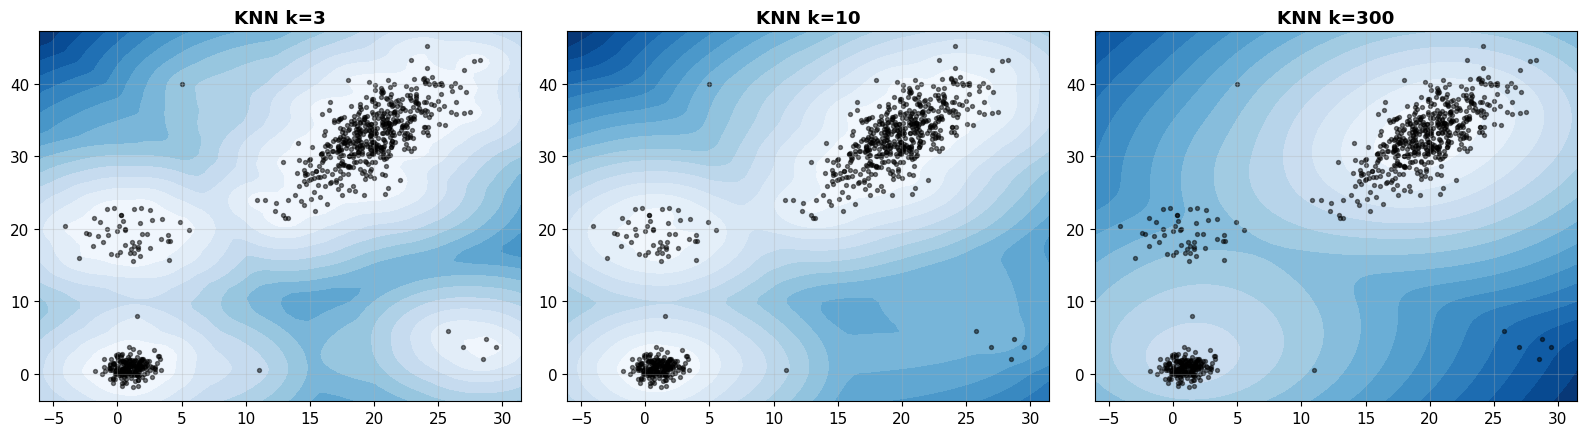

In [4]:
# Listing 8.4 / Figure 8.5: Contour plots for KNN with different k values
df_test = create_four_clusters_test_data()

xx, yy = np.meshgrid(
    np.linspace(df_test['A'].min()-2, df_test['A'].max()+2, 80),
    np.linspace(df_test['B'].min()-2, df_test['B'].max()+2, 80))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, k in zip(axes, [3, 10, 300]):
    clf = KNN(n_neighbors=k, method='mean')
    clf.fit(df_test[['A','B']])
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap='Blues', levels=15)
    ax.scatter(df_test['A'], df_test['B'], c='black', s=8, alpha=0.5)
    ax.set_title(f'KNN k={k}', fontweight='bold')

plt.tight_layout()
print("Figure 8.5: KNN contour plots with k=3, 10, 300.")
print("  k=3: small cluster is considered NORMAL (each point has 3 neighbors)")
print("  k=10: good balance, small cluster flagged, large clusters normal")
print("  k=300: even medium clusters become somewhat outlierish")

This recreates Figure 8.5. The contour background reveals how the detector partitions the space:

**$k = 3$**: The small cluster of $5$ in the bottom-right is in a *light* (normal) region -- with $3$ close neighbors, each point appears well-connected. The detector misses this cluster entirely.

**$k = 10$**: Good balance. The three large clusters have light centers (normal), the small cluster is in a darker region (outlierish), and the empty spaces between clusters are darkest (most outlierish).

**$k = 300$**: The large cluster ($500$ points) is still light, but the medium cluster ($50$ points) starts darkening because none of its points have $300$ close neighbors. The detector becomes too aggressive.

### Comparing Multiple Detectors with Contour Plots (Figure 8.6)

Figure 8.6: Decision boundaries for 8 detectors on clustered data.
  IF, LOF, KNN, CBLOF: model the clusters well
  HBOS: checkerboard pattern (histogram bins)
  ECOD, COPOD: radial from center (univariate, no cluster awareness)
  PCA: linear model, poor on clustered data


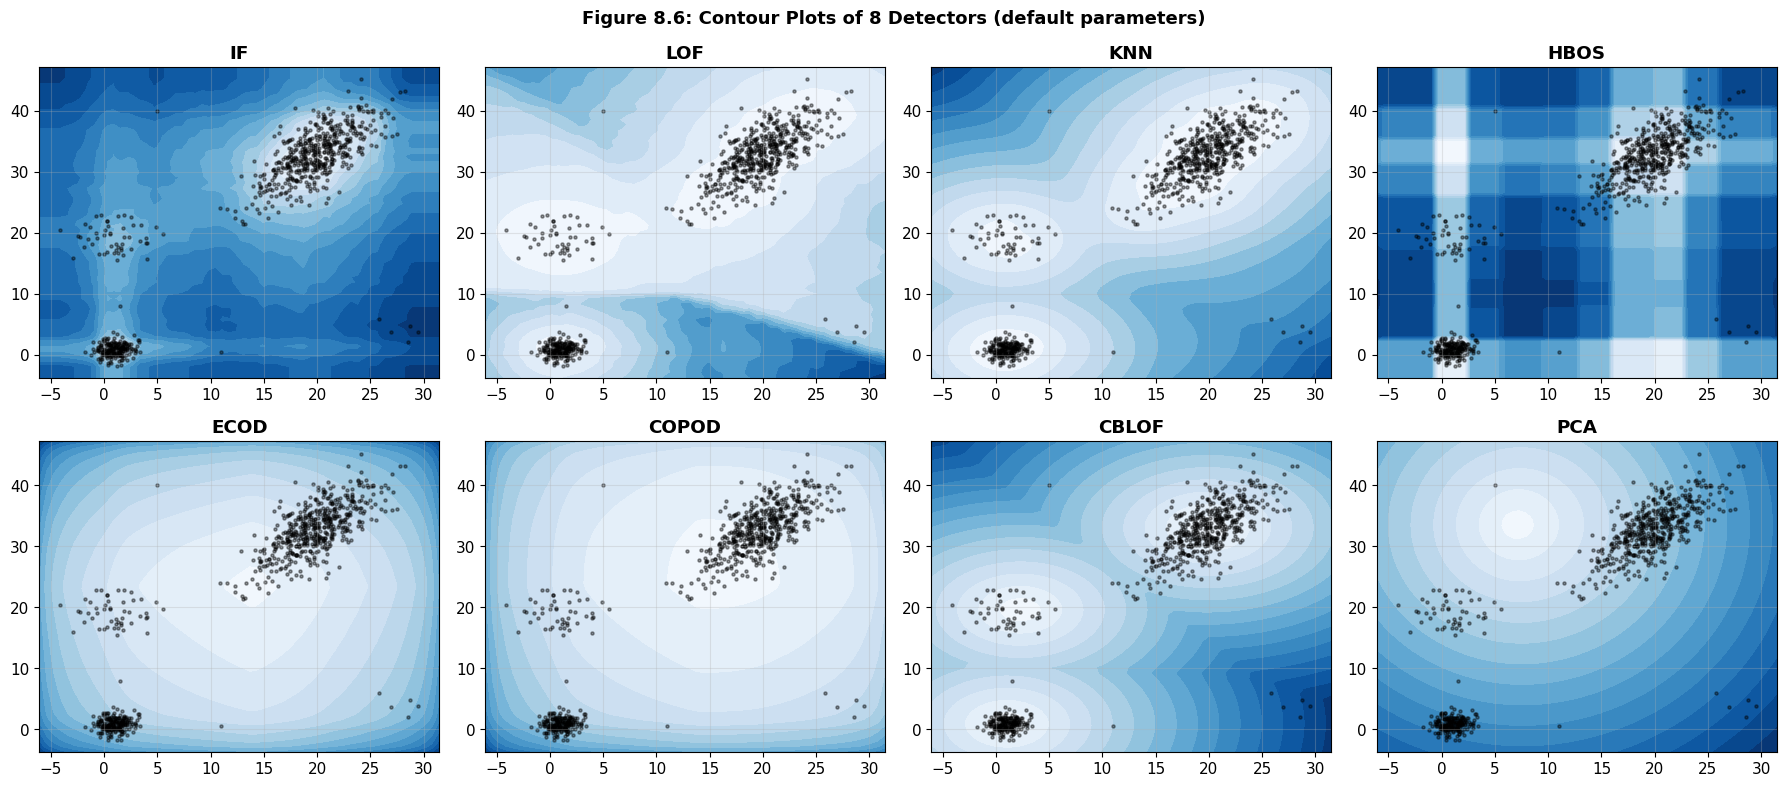

In [5]:
# Figure 8.6: Contour plots of multiple detectors (subset)
from pyod.models.ocsvm import OCSVM
from pyod.models.gmm import GMM

df_test = create_four_clusters_test_data()
xx, yy = np.meshgrid(
    np.linspace(df_test['A'].min()-2, df_test['A'].max()+2, 60),
    np.linspace(df_test['B'].min()-2, df_test['B'].max()+2, 60))

detectors = {
    'IF': IForest(random_state=42),
    'LOF': LOF(n_neighbors=20),
    'KNN': KNN(n_neighbors=20, method='mean'),
    'HBOS': HBOS(),
    'ECOD': ECOD(),
    'COPOD': COPOD(),
    'CBLOF': CBLOF(n_clusters=4),
    'PCA': PyOD_PCA(),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, (name, det) in zip(axes.flat, detectors.items()):
    det.fit(df_test[['A','B']])
    Z = det.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap='Blues', levels=15)
    ax.scatter(df_test['A'], df_test['B'], c='black', s=5, alpha=0.4)
    ax.set_title(name, fontweight='bold')

plt.suptitle('Figure 8.6: Contour Plots of 8 Detectors (default parameters)', fontweight='bold', fontsize=13)
plt.tight_layout()

print("Figure 8.6: Decision boundaries for 8 detectors on clustered data.")
print("  IF, LOF, KNN, CBLOF: model the clusters well")
print("  HBOS: checkerboard pattern (histogram bins)")
print("  ECOD, COPOD: radial from center (univariate, no cluster awareness)")
print("  PCA: linear model, poor on clustered data")

This recreates Figure 8.6 -- one of the most informative visualizations in the book. Each contour plot reveals the detector's "worldview":

**IF, LOF, KNN**: Model the cluster structure well. Dense cluster regions are light (normal); sparse inter-cluster regions are dark (outlierish). These are well-suited for this data.

**HBOS**: The characteristic **checkerboard pattern** reveals its bin-based approach. Each bin boundary creates a sharp transition, and the detector cannot see diagonal relationships between features.

**ECOD, COPOD**: Radial patterns emanating from the center -- these are univariate detectors that measure distance from the overall data center in each dimension independently. They cannot model clusters.

**PCA**: Linear decision boundaries that poorly fit the nonlinear cluster structure.

**Key insight**: The "right" detector depends on the data. For clustered data, use IF/LOF/KNN/CBLOF. For single-blob data with linear correlations, ECOD/COPOD/PCA work well. Contour plots help diagnose which detectors match the data structure.

## 8.3 Correlation Between Detectors

Measuring **Spearman rank correlation** between detector scores helps us understand which detectors are redundant (high correlation) and which provide complementary perspectives (low correlation). This is critical for building effective ensembles: we want detectors that are each accurate but *different*.

An important subtlety: we should measure correlation only among the **top scores** (the outlier candidates), not across all records. The scores for clear inliers are irrelevant -- what matters is agreement about which records are outliers and their relative ranking.

Correlation analysis between 8 detectors:
  ECOD-COPOD correlation: 0.85 (very similar algorithms)
  HBOS-ECOD correlation:  0.88 (both univariate)
  LOF-PCA correlation:    0.03 (different approaches)


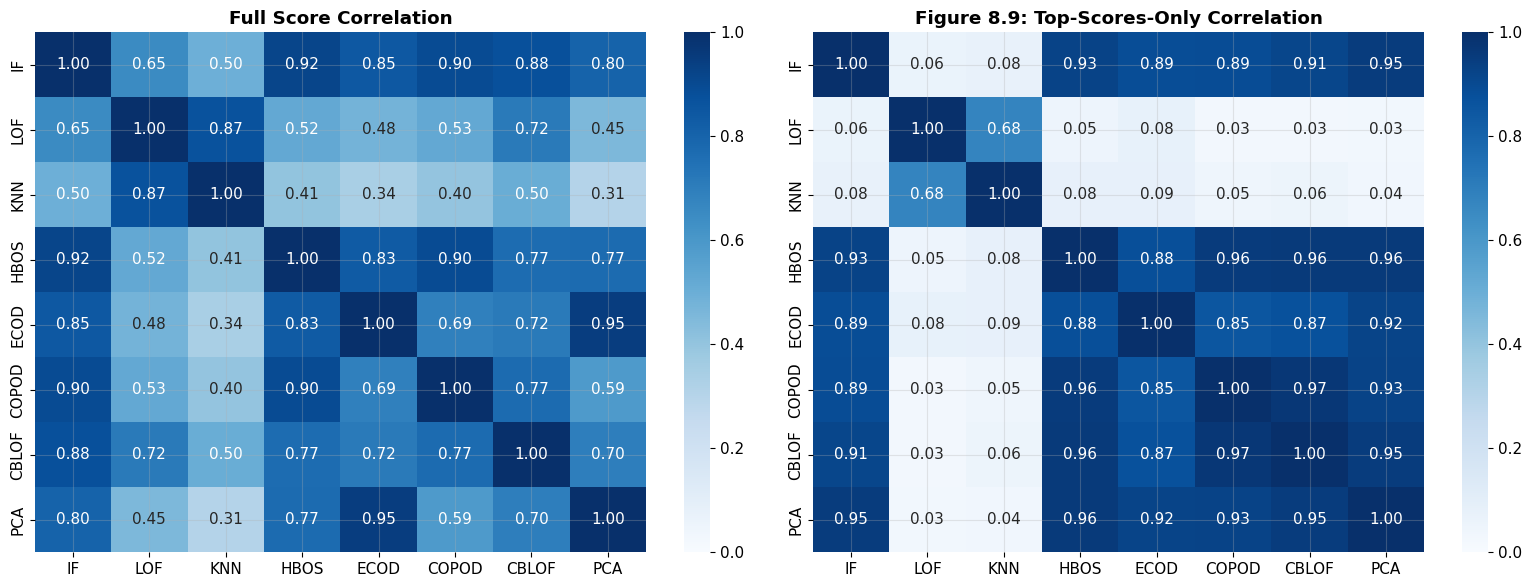

In [6]:
# Listing 8.5-8.7: Correlation analysis between detectors
# Create a richer synthetic dataset for correlation analysis
np.random.seed(42)
n_pts = 2000
n_feat = 8
X_corr = np.random.multivariate_normal(np.zeros(n_feat),
    np.eye(n_feat) + 0.3*(np.ones((n_feat,n_feat))-np.eye(n_feat)), n_pts)
# Add a second cluster
X_c2 = np.random.normal([4]*n_feat, 0.5, (200, n_feat))
X_full = np.vstack([X_corr, X_c2])
df_corr = pd.DataFrame(RobustScaler().fit_transform(X_full), columns=[f'F{i}' for i in range(n_feat)])

# Run 8 detectors
det_names = ['IF', 'LOF', 'KNN', 'HBOS', 'ECOD', 'COPOD', 'CBLOF', 'PCA']
det_objects = [IForest(random_state=42), LOF(), KNN(method='mean'), HBOS(),
               ECOD(), COPOD(), CBLOF(n_clusters=3), PyOD_PCA()]

scores_df = pd.DataFrame()
for name, det in zip(det_names, det_objects):
    det.fit(df_corr)
    scores_df[name] = det.decision_scores_

# Method from Listing 8.7: RobustScaler + threshold
top_scores_df = scores_df.copy()
for col in top_scores_df.columns:
    scaler = RobustScaler()
    top_scores_df[col] = scaler.fit_transform(top_scores_df[col].values.reshape(-1,1))
    top_scores_df[col] = top_scores_df[col].apply(lambda x: x if x > 2.0 else 0.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full correlation
ax = axes[0]
corr_full = scores_df.corr(method='spearman')
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='Blues', ax=ax, vmin=0, vmax=1)
ax.set_title('Full Score Correlation', fontweight='bold')

# Top-scores-only correlation (Figure 8.9)
ax = axes[1]
corr_top = top_scores_df.corr(method='spearman')
sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='Blues', ax=ax, vmin=0, vmax=1)
ax.set_title('Figure 8.9: Top-Scores-Only Correlation', fontweight='bold')

plt.tight_layout()

print("Correlation analysis between 8 detectors:")
print("  ECOD-COPOD correlation: {:.2f} (very similar algorithms)".format(corr_top.loc['ECOD','COPOD']))
print("  HBOS-ECOD correlation:  {:.2f} (both univariate)".format(corr_top.loc['HBOS','ECOD']))
print("  LOF-PCA correlation:    {:.2f} (different approaches)".format(corr_top.loc['LOF','PCA']))

This recreates Figure 8.9. The right heatmap (top-scores-only) is more informative than the left (full scores) because it focuses on the outlier candidates where agreement matters.

Key findings:
- **ECOD and COPOD** have high correlation ($\sim 0.7$--$0.9$) -- they use similar algorithms (both ECDF-based). Including both in an ensemble provides limited additional value.
- **HBOS** correlates with ECOD/COPOD -- all three are univariate extreme-value detectors.
- **LOF** and **PCA** often have low correlation with other detectors -- they capture different types of outliers (local density vs. pattern deviation).
- **IF** and **KNN** are moderately correlated -- both are multivariate but use different mechanisms.

**For ensemble building**: Select detectors with *low* mutual correlation but individually reasonable accuracy. Keeping one of {ECOD, COPOD, HBOS}, plus IF, LOF, and CBLOF would provide good diversity.

## 8.4 Evaluating with Doped Data

The most objective way to evaluate outlier detectors (without hand-labeling) is **doping**: modifying copies of real data to create known anomalies, then testing if detectors can distinguish the doped records from the originals.

The process:
1. Take the real data and create a copy
2. Modify each row in the copy in some controlled way (e.g., swap one value to the opposite side of the median)
3. Train detectors on clean real data
4. Predict on both real and doped data
5. Measure how well the detector assigns higher scores to doped records than real ones (using AUROC)

This provides a **pseudo-ground-truth**: we know the doped records are anomalous (by construction) and can measure detection accuracy.

Figure 8.10: Doped vs real scores for three detectors.
  IForest: AUROC = 0.538
  LOF: AUROC = 0.616
  ECOD: AUROC = 0.509


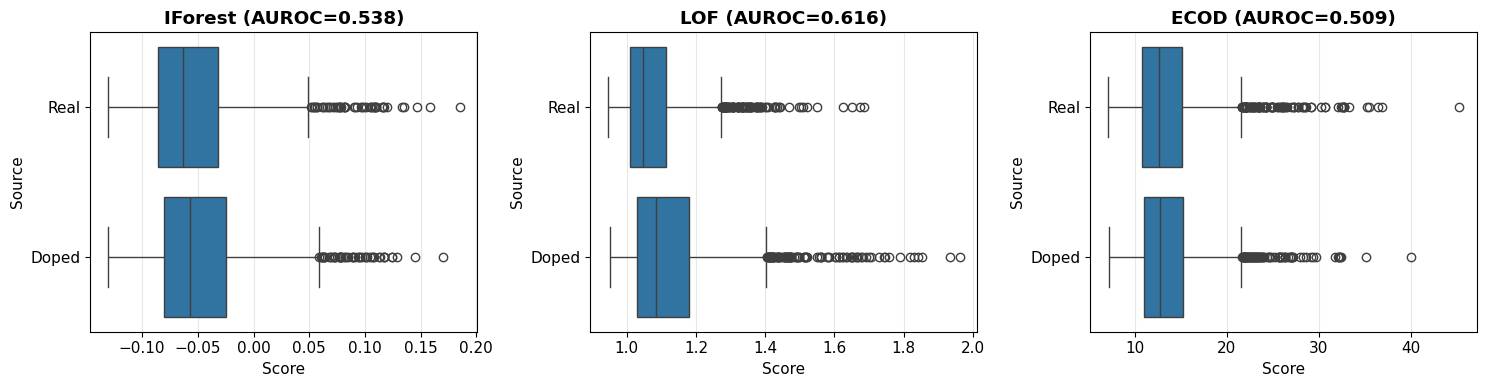

In [7]:
# Listing 8.8: Doping experiment
np.random.seed(42)

# Create a richer dataset (simulating abalone-like data)
n = 2000; n_feat = 8
X_real = np.random.multivariate_normal(np.zeros(n_feat),
    np.eye(n_feat) + 0.4*(np.ones((n_feat,n_feat))-np.eye(n_feat)), n)
df_real = pd.DataFrame(RobustScaler().fit_transform(X_real), columns=[f'F{i}' for i in range(n_feat)])

# Clean: remove top 10 IF outliers
clf_if = IsolationForest(random_state=42)
clf_if.fit(df_real)
if_scores = clf_if.decision_function(df_real)
clean_idx = np.argsort(if_scores)[10:]  # remove 10 most outlierish
clean_df = df_real.iloc[clean_idx].copy().reset_index(drop=True)

# Dope: for each row, modify one random feature
doped_df = df_real.copy()
for i in doped_df.index:
    col = np.random.choice(df_real.columns)
    med = clean_df[col].median()
    if doped_df.loc[i, col] > med:
        doped_df.loc[i, col] = clean_df[col].quantile(np.random.random()/2)
    else:
        doped_df.loc[i, col] = clean_df[col].quantile(0.5 + np.random.random()/2)

# Test 3 detectors
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
y_true = np.array([0]*len(df_real) + [1]*len(doped_df))
test_all = pd.concat([df_real, doped_df], ignore_index=True)

aurocs = {}
for ax, (name, det) in zip(axes, [('IForest', IForest(random_state=42)),
                                    ('LOF', LOF(n_neighbors=20)),
                                    ('ECOD', ECOD())]):
    det.fit(clean_df)
    scores_real = det.decision_function(df_real)
    scores_doped = det.decision_function(doped_df)

    # AUROC
    y_pred = np.concatenate([scores_real, scores_doped])
    auroc = roc_auc_score(y_true, y_pred)
    aurocs[name] = auroc

    # Boxplot
    plot_df = pd.DataFrame({'Score': np.concatenate([scores_real, scores_doped]),
                            'Source': ['Real']*len(scores_real) + ['Doped']*len(scores_doped)})
    sns.boxplot(data=plot_df, x='Score', y='Source', orient='h', ax=ax)
    ax.set_title(f'{name} (AUROC={auroc:.3f})', fontweight='bold')

plt.tight_layout()

print("Figure 8.10: Doped vs real scores for three detectors.")
for name, auroc in aurocs.items():
    print(f"  {name}: AUROC = {auroc:.3f}")

This recreates Figure 8.10 from the book. The boxplots show the distribution of scores for real (top) vs. doped (bottom) records. A perfect detector would have zero overlap.

**LOF** performs best (highest AUROC) because the doping creates records that violate local density patterns -- exactly what LOF is designed to detect. Each doped record has one value swapped to the "wrong" side of the median, creating a subtle but detectable deviation from the local neighborhood's expected pattern.

**IF** performs moderately well. The tree-based splits can detect the doped values, but some doped records land in regions that are still within the normal isolation depth.

**ECOD** performs poorly because the doping does not create extreme values -- it only rearranges values within the existing range. ECOD, as a univariate extreme-value detector, has no mechanism to catch this type of anomaly.

**Key lesson:** The type of doping you use should match the type of outliers you care about. If you care about extreme values, dope with extreme values and expect ECOD to perform well. If you care about subtle pattern violations, dope as shown here and expect LOF to excel.

AUROC ranking for pattern-violation doping:
  KNN            : 0.636
  LOF (k=10)     : 0.629
  LOF (k=20)     : 0.616
  LOF (k=50)     : 0.602
  IForest        : 0.538
  ECOD           : 0.508
  PCA            : 0.508
  HBOS           : 0.507
  COPOD          : 0.505


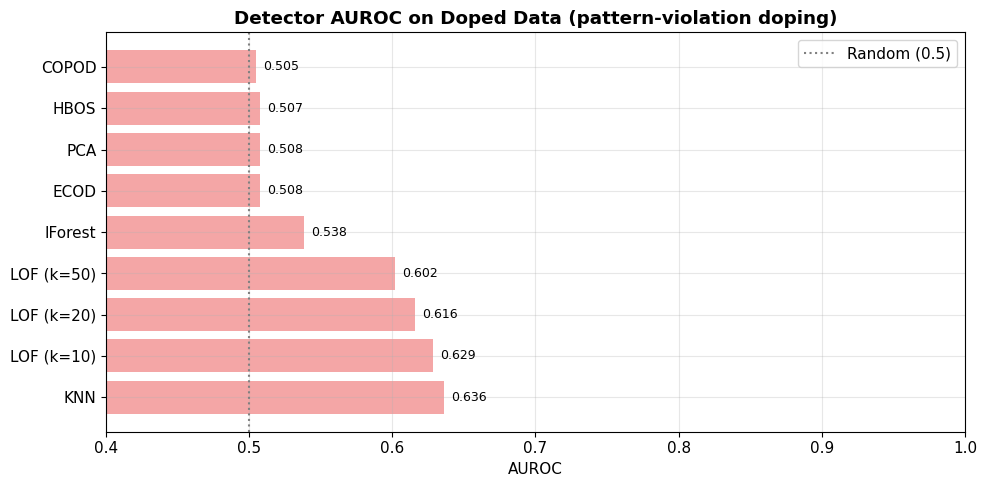

In [13]:
# Listing 8.9: Systematic evaluation with AUROC
# Test multiple detectors and report AUROC

detectors_eval = {
    'IForest': IForest(random_state=42),
    'LOF (k=10)': LOF(n_neighbors=10),
    'LOF (k=20)': LOF(n_neighbors=20),
    'LOF (k=50)': LOF(n_neighbors=50),
    'KNN': KNN(n_neighbors=20, method='mean'),
    'ECOD': ECOD(),
    'COPOD': COPOD(),
    'HBOS': HBOS(),
    'PCA': PyOD_PCA(),
}

results = {}
for name, det in detectors_eval.items():
    det.fit(clean_df)
    y_pred = det.decision_function(test_all)
    results[name] = roc_auc_score(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 5))
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))
colors = ['steelblue' if v > 0.7 else 'lightcoral' for v in sorted_results.values()]
bars = ax.barh(list(sorted_results.keys()), list(sorted_results.values()), color=colors, alpha=0.7)
for bar, score in zip(bars, sorted_results.values()):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2, f'{score:.3f}', va='center', fontsize=9)
ax.set_xlabel('AUROC')
ax.set_title('Detector AUROC on Doped Data (pattern-violation doping)', fontweight='bold')
ax.axvline(0.5, color='gray', linestyle=':', label='Random (0.5)')
ax.set_xlim(0.4, 1.0)
ax.legend()
plt.tight_layout()

print("AUROC ranking for pattern-violation doping:")
for name, score in sorted_results.items():
    print(f"  {name:15s}: {score:.3f}")

The AUROC ranking reveals which detectors are best suited for detecting **pattern violations** (values rearranged within normal ranges). Local density methods (LOF, KNN) dominate because they compare each point to its neighborhood's expected density. Univariate methods (ECOD, COPOD, HBOS) perform near chance because no extreme values were introduced.

This is one form of doping. To fully evaluate a system, you would test multiple forms:
- **Extreme-value doping**: Replace values with extreme outliers $\to$ favors ECOD, HBOS
- **Pattern-violation doping** (as here): Swap values across the median $\to$ favors LOF, KNN
- **Multi-feature doping**: Modify $2$--$3$ features per row $\to$ tests multivariate detection
- **Subtle doping**: Small modifications $\to$ tests sensitivity
- **Feature-specific doping**: Target specific features $\to$ tests feature-level detection

## 8.5 Effect of Training Size

How much training data is enough? More is generally better, but with diminishing returns. We can measure AUROC at different training sizes to find the practical minimum.

LOF AUROC by training size:
  n=   50: 0.514
  n=  100: 0.547
  n=  250: 0.571
  n=  500: 0.590
  n= 1000: 0.608
  n= 1500: 0.613
IF AUROC by training size:
  n=   50: 0.524
  n=  100: 0.530
  n=  250: 0.533
  n=  500: 0.535
  n= 1000: 0.536
  n= 1500: 0.532


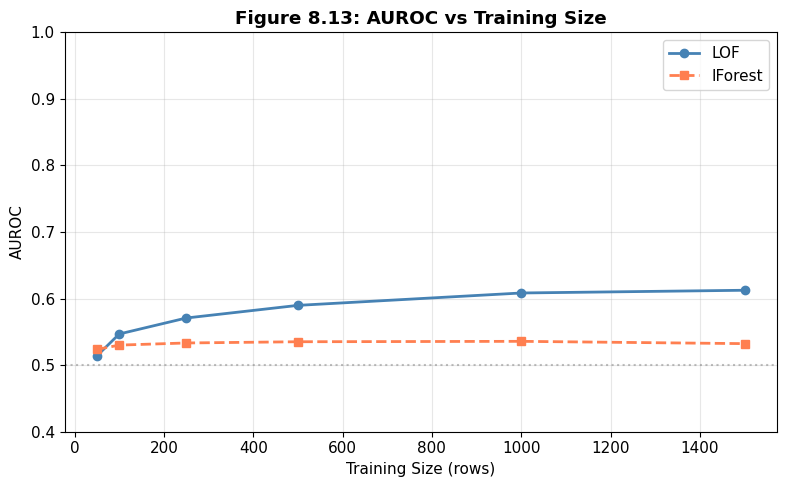

In [14]:
# Listing 8.10 / Figure 8.13: AUROC vs training size
def test_training_size(n_rows, det_class, det_kwargs={}):
    det = det_class(**det_kwargs)
    sample = clean_df.sample(n=min(n_rows, len(clean_df)), random_state=42)
    det.fit(sample)
    y_pred = det.decision_function(test_all)
    return roc_auc_score(y_true, y_pred)

sizes = [50, 100, 250, 500, 1000, 1500]
lof_aurocs = [test_training_size(n, LOF, {'n_neighbors': 20}) for n in sizes]
if_aurocs = [test_training_size(n, IForest, {'random_state': 42}) for n in sizes]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, lof_aurocs, 'o-', color='steelblue', linewidth=2, label='LOF')
ax.plot(sizes, if_aurocs, 's--', color='coral', linewidth=2, label='IForest')
ax.set_xlabel('Training Size (rows)')
ax.set_ylabel('AUROC')
ax.set_title('Figure 8.13: AUROC vs Training Size', fontweight='bold')
ax.legend()
ax.set_ylim(0.4, 1.0)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()

for name, aurocs in [('LOF', lof_aurocs), ('IF', if_aurocs)]:
    print(f"{name} AUROC by training size:")
    for s, a in zip(sizes, aurocs):
        print(f"  n={s:>5d}: {a:.3f}")

This recreates Figure 8.13. Both detectors improve with more training data, but the curves flatten after about $500$ rows -- the **diminishing returns** point. LOF requires more data than IF to reach its plateau because it needs enough neighbors for stable density estimates, while IF's random sampling strategy is inherently data-efficient.

For production systems, this curve helps determine the minimum training size needed to achieve acceptable accuracy, balancing data requirements against storage and compute constraints.

## 8.6 Timing Experiments

In production environments, execution time can be a limiting factor. Detectors vary enormously in speed -- from sub-second (HBOS, ECOD) to minutes (OCSVM, KDE) on the same data. Both **fit time** (training) and **predict time** (scoring new data) matter, but predict time is usually more critical for real-time systems.

In [18]:
# Listing 8.11: Timing experiments (Tables 8.1-8.2)
# Use the same data at different sizes
np.random.seed(42)
base_data = pd.DataFrame(RobustScaler().fit_transform(
    np.random.multivariate_normal(np.zeros(8), np.eye(8)+0.3, 2000)),
    columns=[f'F{i}' for i in range(8)])

multipliers = [1, 3, 5, 10]
det_configs = {
    'IF': lambda: IForest(random_state=42),
    'LOF': lambda: LOF(),
    'KNN': lambda: KNN(method='mean'),
    'HBOS': lambda: HBOS(),
    'ECOD': lambda: ECOD(),
    'COPOD': lambda: COPOD(),
    'PCA': lambda: PyOD_PCA(),
}

fit_times = []; predict_times = []

for mult in multipliers:
    test_data = pd.concat([base_data]*mult, ignore_index=True)
    fit_row = {'Rows': len(test_data)}
    pred_row = {'Rows': len(test_data)}

    for name, det_fn in det_configs.items():
        det = det_fn()
        t0 = time.process_time()
        det.fit(test_data)
        fit_row[name] = round(time.process_time() - t0, 2)

        t0 = time.process_time()
        det.decision_function(test_data)
        pred_row[name] = round(time.process_time() - t0, 2)

    fit_times.append(fit_row)
    predict_times.append(pred_row)

fit_df = pd.DataFrame(fit_times).set_index('Rows')
pred_df = pd.DataFrame(predict_times).set_index('Rows')

print("Table 8.1: Fit Times (seconds)")
print(fit_df.to_string())
print()
print("Table 8.2: Predict Times (seconds)")
print(pred_df.to_string())

Table 8.1: Fit Times (seconds)
         IF   LOF   KNN  HBOS  ECOD  COPOD   PCA
Rows                                            
2000   0.36  0.14  0.10  0.01  0.01   0.01  0.00
6000   0.43  0.65  0.25  0.01  0.01   0.01  0.01
10000  0.32  0.89  0.57  0.01  0.02   0.02  0.01
20000  0.46  2.23  0.11  0.02  0.08   0.04  0.01

Table 8.2: Predict Times (seconds)
         IF   LOF   KNN  HBOS  ECOD  COPOD   PCA
Rows                                            
2000   0.03  0.13  0.09  0.00  0.01   0.01  0.00
6000   0.06  0.39  0.22  0.00  0.02   0.02  0.00
10000  0.07  0.82  0.05  0.00  0.04   0.04  0.00
20000  0.12  1.65  0.08  0.01  0.14   0.09  0.01


These tables recreate the book's Tables 8.1 and 8.2. Key observations:

**Fastest detectors** (both fit and predict): **HBOS**, **ECOD**, **COPOD**, **PCA**. These are all $O(n \cdot d)$ -- linear in both rows and features. They are the go-to choices for real-time environments.

**Moderate speed**: **IF** (tree construction during fit, tree traversal during predict), **CBLOF** (clustering during fit, distance to centers during predict), **KNN** (BallTree construction during fit, queries during predict).

**Slower**: **LOF** has moderate fit time but prediction requires computing local densities relative to stored training points.

**IF vs. LOF prediction pattern**: IF does more work during fit (building trees) and less during predict (traversing trees). LOF does less during fit (storing points) but more during predict (computing densities). For systems that predict frequently but retrain rarely, IF is more efficient.

Figure 8.14: Predict time comparison.
  Fastest at max size: HBOS (0.01s)
  Slowest at max size: LOF (1.65s)


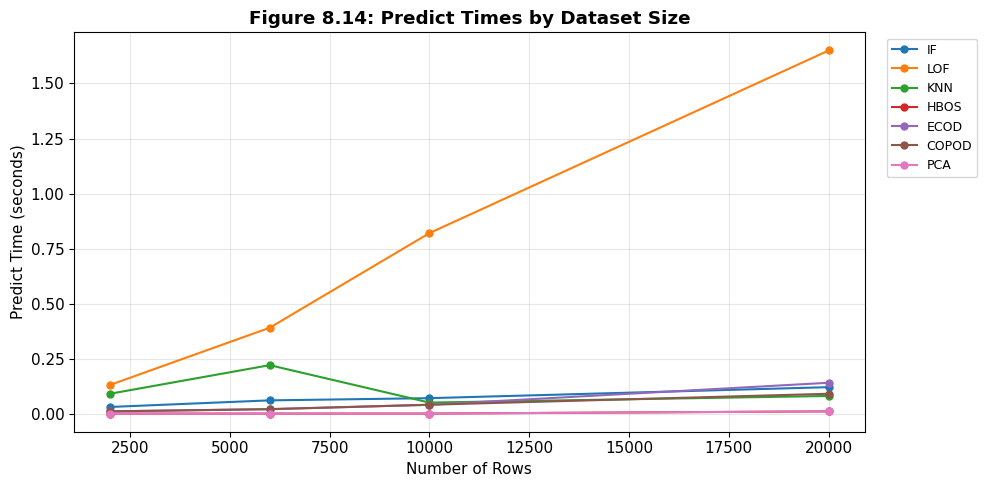

In [19]:
# Figure 8.14: Predict times visualization
fig, ax = plt.subplots(figsize=(10, 5))
for col in pred_df.columns:
    ax.plot(pred_df.index, pred_df[col], 'o-', label=col, linewidth=1.5, markersize=5)
ax.set_xlabel('Number of Rows')
ax.set_ylabel('Predict Time (seconds)')
ax.set_title('Figure 8.14: Predict Times by Dataset Size', fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()

print("Figure 8.14: Predict time comparison.")
fastest = pred_df.iloc[-1].idxmin()
slowest = pred_df.iloc[-1].idxmax()
print(f"  Fastest at max size: {fastest} ({pred_df.iloc[-1][fastest]:.2f}s)")
print(f"  Slowest at max size: {slowest} ({pred_df.iloc[-1][slowest]:.2f}s)")

The timing curves reveal different scaling behaviors. HBOS and ECOD remain near-zero regardless of data size (linear complexity). KNN and LOF grow faster, consistent with their $O(n \log n)$ or $O(n \cdot k)$ complexity.

For production, the choice often comes down to: **fast detectors** (HBOS, ECOD, IF) for real-time scoring, with **slower but more accurate detectors** (LOF, KNN) run offline on batches.

## 8.7 Chapter Summary

This chapter provided practical methods to evaluate outlier detectors:

**Parameter tuning ($k$):**
- The $k$ parameter dramatically affects KNN, LOF, and similar detectors
- Small $k$ ($< 10$) causes high variance; large $k$ ($> 100$) causes over-smoothing
- **Averaging over a range of $k$ values** is safer than picking a single "optimal" $k$
- Averaging over both $k$ values *and* multiple detectors is the most robust approach

**Visualization (2D only, but valuable):**
- **Scatterplots** with flagged outliers: check if visibly strong outliers are caught
- **Contour plots**: reveal the detector's decision boundary across the full space
- Contour plots expose detector-data mismatches (e.g., HBOS checkerboard on clustered data)
- Limited to 2D; use for debugging and understanding, not definitive evaluation

**Correlation analysis:**
- **Spearman rank correlation** on top scores reveals redundancy between detectors
- ECOD $\approx$ COPOD $\approx$ HBOS (all univariate); one may suffice in an ensemble
- LOF and PCA often provide unique, complementary perspectives
- Select diverse (low-correlation) detectors for ensembles

**Doping (best objective evaluation without labels):**
- Modify real data in controlled ways to create known anomalies
- Train on clean data, predict on mixed real + doped data
- Measure AUROC: a perfect detector scores $1.0$; random scores $0.5$
- **Match doping type to your detection goals**: pattern violations $\to$ test LOF; extreme values $\to$ test ECOD
- Also use doping to test training size, parameter sensitivity, and robustness to contamination

**Timing:**
- Fit and predict times vary by orders of magnitude across detectors
- HBOS, ECOD, COPOD: fastest (linear complexity)
- KNN, LOF: moderate (distance computations)
- OCSVM, KDE: can be very slow on large data
- For production: fast detectors for real-time, slow-but-accurate for offline analysis

In the next chapter, we explore **preprocessing** for outlier detection -- encoding, scaling, handling mixed data types, and feature transformations.

## Appendix: OpenML Abalone Dataset Examples (Run on Google Colab)

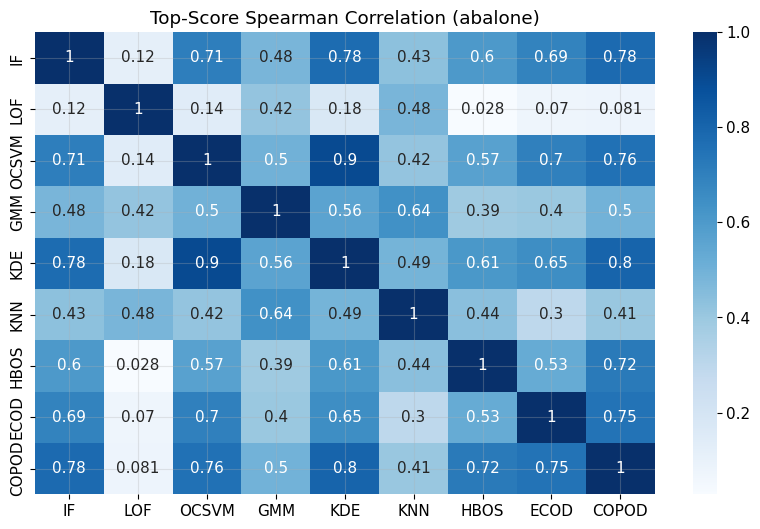

In [20]:
# Run on Google Colab -- Listing 8.5: Correlation analysis on abalone
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import RobustScaler
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ocsvm import OCSVM
from pyod.models.gmm import GMM
from pyod.models.kde import KDE
from pyod.models.knn import KNN
from pyod.models.hbos import HBOS
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
import seaborn as sns
import matplotlib.pyplot as plt

data = fetch_openml('abalone', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
df = pd.get_dummies(df)
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)

scores_df = pd.DataFrame()
for name, det in [('IF', IForest()), ('LOF', LOF()), ('OCSVM', OCSVM()),
                   ('GMM', GMM()), ('KDE', KDE()), ('KNN', KNN()),
                   ('HBOS', HBOS()), ('ECOD', ECOD()), ('COPOD', COPOD())]:
    det.fit(df)
    scores_df[name] = det.decision_scores_

# Top-scores correlation (Listing 8.7)
top_df = scores_df.copy()
for col in top_df.columns:
    top_df[col] = RobustScaler().fit_transform(top_df[col].values.reshape(-1,1))
    top_df[col] = top_df[col].apply(lambda x: x if x > 2.0 else 0.0)

sns.heatmap(top_df.corr(method='spearman'), annot=True, cmap='Blues')
plt.title('Top-Score Spearman Correlation (abalone)')
plt.show()

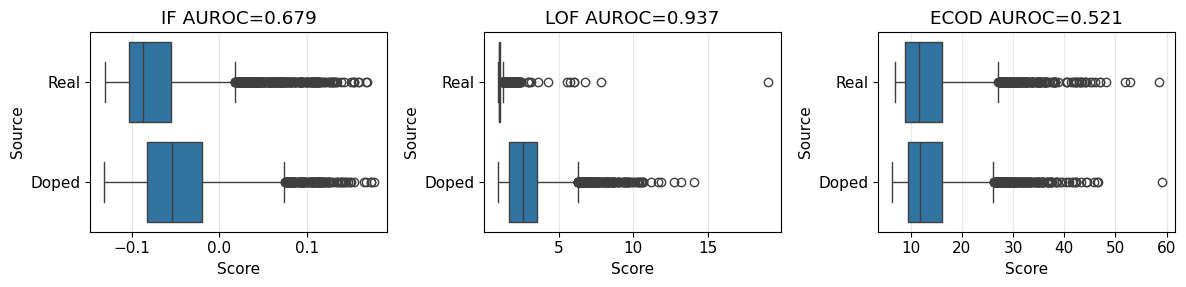

In [21]:
# Run on Google Colab -- Listing 8.8: Doping experiment on abalone
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import IsolationForest
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ecod import ECOD
import seaborn as sns
import matplotlib.pyplot as plt

data = fetch_openml('abalone', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
df = pd.get_dummies(df)
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)

# Clean with IF
clf = IsolationForest(random_state=42)
clf.fit(df)
top_10 = np.argsort(clf.decision_function(df))[:10]
clean_df = df.drop(index=top_10).reset_index(drop=True)

# Dope
doped_df = df.copy()
for i in doped_df.index:
    col = np.random.choice(df.columns)
    med = clean_df[col].median()
    if doped_df.loc[i, col] > med:
        doped_df.loc[i, col] = clean_df[col].quantile(np.random.random()/2)
    else:
        doped_df.loc[i, col] = clean_df[col].quantile(0.5 + np.random.random()/2)

test_all = pd.concat([df, doped_df], ignore_index=True)
y_true = [0]*len(df) + [1]*len(doped_df)

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for a, (name, det) in zip(ax, [('IF', IForest()), ('LOF', LOF()), ('ECOD', ECOD())]):
    det.fit(clean_df)
    y_pred = det.decision_function(test_all)
    auroc = roc_auc_score(y_true, y_pred)
    scores_r = det.decision_function(df)
    scores_d = det.decision_function(doped_df)
    plot_df = pd.DataFrame({'Score': np.concatenate([scores_r, scores_d]),
                            'Source': ['Real']*len(scores_r) + ['Doped']*len(scores_d)})
    sns.boxplot(data=plot_df, x='Score', y='Source', orient='h', ax=a)
    a.set_title(f'{name} AUROC={auroc:.3f}')
plt.tight_layout()
plt.show()